# ComptonSuite IO Module - Hands-On Exploration

This notebook lets you **feel** how the IO module works by:
- Creating electron beams with different physical parameters
- Sampling macroparticles from beam descriptions
- Propagating beams through vacuum
- Fitting macroparticles back to beam parameters
- Running physics models and analyzing results

The goal is to understand the **data flow** from beam description → sampling → physics → results.

In [2]:
import numpy as np
import pint

ureg = pint.UnitRegistry(system='cgs')
Q_ = ureg.Quantity

In [3]:
%matplotlib widget
import matplotlib.pyplot as plt


In [4]:
from scipy.fft import fft, fftfreq, fftshift, rfft

In [27]:
xs = np.linspace(-14.0, 26.0, 512)
ys = np.exp(-xs**2/2) / np.sqrt(2*np.pi)

In [28]:
np.trapezoid(ys,xs)

np.float64(1.0000000000000002)

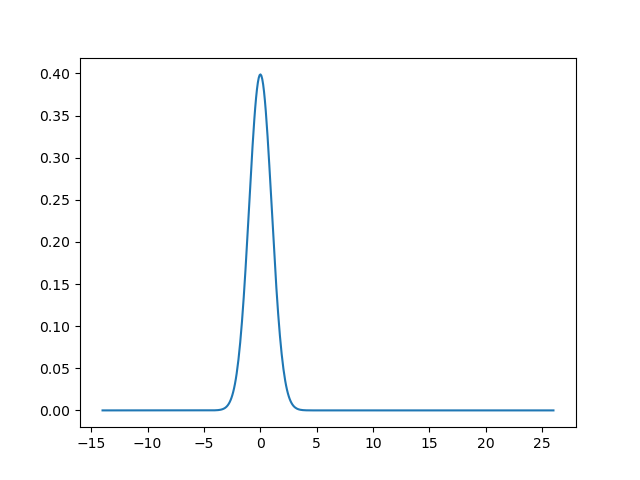

In [29]:
fig,ax=plt.subplots()
ax.plot(xs,ys)

In [30]:
fft_y = fft(ys)
fft_x = fftfreq(xs.size, np.diff(xs)[0])

(-1.0, 1.0)

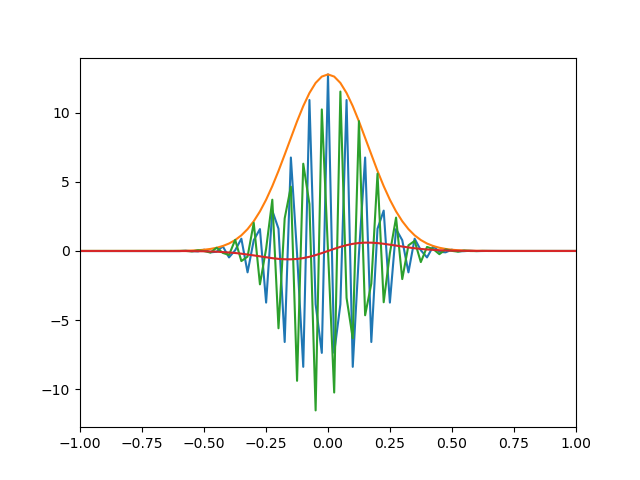

In [31]:
fig,ax = plt.subplots()
ax.plot(fftshift(fft_x),fftshift(np.real(fft_y)))
ax.plot(fftshift(fft_x),fftshift(np.real(fft_y*np.exp(1j*fft_x*(-xs[-1])*2*np.pi))))

ax.plot(fftshift(fft_x),fftshift(np.imag(fft_y)))
ax.plot(fftshift(fft_x),fftshift(np.imag(fft_y*np.exp(1j*fft_x*(-xs[-1])*2*np.pi))))

ax.set_xlim(-1,1)

In [8]:
Q_(1, "vacuum_permittivity").to_base_units()

<Quantity(8.85418782e-21, 'ampere ** 2 * second ** 4 / gram / centimeter ** 3')>

In [19]:
Np = 1024

length_unit = "cm"

mx = Q_(1.0, "meter")
sx = Q_(0.1, "meter")

x = Q_(np.random.normal(mx.to(length_unit).magnitude, sx.to(length_unit).magnitude, Np), length_unit)
y = Q_(np.random.normal(1.0, 0.1, Np), "meter")

thx = Q_(np.random.normal(0.0, 0.1, Np), "radian")
thy = Q_(np.random.normal(0.0, 0.1, Np), "radian")


units = [x.u, thx.u, y.u, thy.u]
unit_matrix = [[units[i] * units[j] for j in range(4)] 
                   for i in range(4)]

X = np.stack([x.magnitude, thx.magnitude, y.magnitude, thy.magnitude], axis=1)

# Center data
mu = np.mean(X, axis=0)
Xc = X - mu

# Compute covariance (biased for population parameters)
Sigma = np.cov(Xc, rowvar=False, bias=True)

# Extract parameters
ix, ixp, iy, iyp = range(4)

# Transverse emittance
emit_x = Q_(np.sqrt(Sigma[ix, ix] * Sigma[ixp, ixp] - Sigma[ix, ixp]**2), x.u*thx.u)
emit_y = Q_(np.sqrt(Sigma[iy, iy] * Sigma[iyp, iyp] - Sigma[iy, iyp]**2), y.u*thy.u)

In [15]:
emit_x

<Quantity(0.0100171643, 'meter * radian')>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from compton_suite.io.bunch import (
    GaussianElectronBeam, MacroBunch, BeamFittedParams,
    sample_gaussian_bunch, sample_gaussian_canonical,
    fit_gaussian, fit_beam_full, drift,
    beam_from_shared_fields
)
from compton_suite.io.constants import MEC2_EV, E_CHARGE, C_LIGHT
from compton_suite.io.laser import GaussianParaxialLaser, a0_from_fields, focal_radii_m
from compton_suite.io.collision import build_params

# Plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

ModuleNotFoundError: No module named 'gfrg'

## 1. Physical Constants

First, let's see the physical constants we're working with.

In [ ]:
print("Physical Constants:")
print(f"  Electron rest mass energy: {MEC2_EV:.6f} eV")
print(f"  Elementary charge: {E_CHARGE:.6e} C")
print(f"  Speed of light: {C_LIGHT:.6e} m/s")
print(f"  m_e c^2 in MeV: {MEC2_EV/1e6:.6f} MeV")

## 2. Creating Electron Beams

Let's create different electron beams and understand their parameters.

In [ ]:
# Example 1: High-energy beam (like at LCLS)
beam_high_energy = GaussianElectronBeam(
    bunch_charge_C=100e-12,        # 100 pC
    kinetic_energy_eV=500e6,       # 500 MeV
    rel_energy_spread_rms=0.001,   # 0.1% energy spread
    sigma_x_m=100e-6,              # 100 um beam size
    sigma_y_m=100e-6,              # 100 um beam size
    emit_geom_x_m=10e-9,           # 10 nm geometric emittance
    emit_geom_y_m=10e-9,           # 10 nm geometric emittance
    sigma_t_s=1e-12,               # 1 ps bunch duration
    sigma_pz=0.001                 # 0.1% momentum spread
)

print("High-energy beam (500 MeV):")
print(f"  Gamma: {beam_high_energy.gamma0:.2f}")
print(f"  Beta: {beam_high_energy.beta0:.6f}")
print(f"  Number of electrons: {beam_high_energy.N_e:.2e}")
print(f"  Divergence x: {beam_high_energy.divergence_x_rad*1e3:.3f} mrad")
print(f"  Beta star x: {beam_high_energy.beta_star_x_m*1e3:.2f} mm")
print(f"  Peak current: {beam_high_energy.peak_current_A:.2f} A")
print(f"  Peak density: {beam_high_energy.peak_density_m3:.2e} m^-3")

In [ ]:
# Example 2: Low-energy beam (like at FERMI)
beam_low_energy = GaussianElectronBeam(
    bunch_charge_C=500e-12,        # 500 pC
    kinetic_energy_eV=100e6,       # 100 MeV
    rel_energy_spread_rms=0.005,   # 0.5% energy spread
    sigma_x_m=50e-6,               # 50 um beam size
    sigma_y_m=50e-6,               # 50 um beam size
    emit_geom_x_m=1e-6,            # 1 um geometric emittance
    emit_geom_y_m=1e-6,            # 1 um geometric emittance
    sigma_t_s=0.5e-12,             # 0.5 ps bunch duration
    sigma_pz=0.005                 # 0.5% momentum spread
)

print("Low-energy beam (100 MeV):")
print(f"  Gamma: {beam_low_energy.gamma0:.2f}")
print(f"  Beta: {beam_low_energy.beta0:.6f}")
print(f"  Number of electrons: {beam_low_energy.N_e:.2e}")
print(f"  Divergence x: {beam_low_energy.divergence_x_rad*1e3:.3f} mrad")
print(f"  Beta star x: {beam_low_energy.beta_star_x_m*1e3:.2f} mm")

## 3. Sampling Macroparticles

Now let's sample macroparticles from the beam description. This is where the **canonical sampling** with mass-shell enforcement happens.

In [ ]:
# Sample from the high-energy beam
rng = np.random.default_rng(42)
n_particles = 10000

bunch_high = sample_gaussian_bunch(beam_high_energy, n_particles, rng=rng)

print(f"Sampled {bunch_high.n_particles} particles")
print(f"Total charge: {bunch_high.N_e * E_CHARGE:.2e} C")
print(f"Weight per particle: {bunch_high.weight:.2e} electrons/macroparticle")

# Check mass-shell constraint
pz = np.sqrt((bunch_high.gamma**2 - 1) / (1 + bunch_high.thx**2 + bunch_high.thy**2))
px = bunch_high.thx * pz
py = bunch_high.thy * pz

gamma_sq = bunch_high.gamma**2
p_sq = 1.0 + px**2 + py**2 + pz**2

print(f"\nMass-shell check (gamma^2 vs 1+p^2):")
print(f"  Max relative error: {np.max(np.abs(gamma_sq - p_sq) / gamma_sq):.2e}")

In [ ]:
# Visualize the sampled bunch
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Transverse phase space
axes[0, 0].scatter(bunch_high.x * 1e6, bunch_high.thx * 1e3, s=1, alpha=0.3)
axes[0, 0].set_xlabel('x [um]')
axes[0, 0].set_ylabel('thx [mrad]')
axes[0, 0].set_title('X-X\' Phase Space')

axes[0, 1].scatter(bunch_high.y * 1e6, bunch_high.thy * 1e3, s=1, alpha=0.3)
axes[0, 1].set_xlabel('y [um]')
axes[0, 1].set_ylabel('thy [mrad]')
axes[0, 1].set_title('Y-Y\' Phase Space')

# Longitudinal phase space
axes[0, 2].scatter(bunch_high.z * 1e6, bunch_high.gamma, s=1, alpha=0.3)
axes[0, 2].set_xlabel('z [um]')
axes[0, 2].set_ylabel('gamma')
axes[0, 2].set_title('Z-gamma Phase Space')

# Histograms
axes[1, 0].hist(bunch_high.x * 1e6, bins=50, alpha=0.7)
axes[1, 0].set_xlabel('x [um]')
axes[1, 0].set_ylabel('Count')
axes[1, 0].set_title('X Distribution')

axes[1, 1].hist(bunch_high.thx * 1e3, bins=50, alpha=0.7)
axes[1, 1].set_xlabel('thx [mrad]')
axes[1, 1].set_ylabel('Count')
axes[1, 1].set_title('Angle X Distribution')

axes[1, 2].hist(bunch_high.gamma, bins=50, alpha=0.7)
axes[1, 2].set_xlabel('gamma')
axes[1, 2].set_ylabel('Count')
axes[1, 2].set_title('Gamma Distribution')

plt.tight_layout()
plt.show()

## 4. Fitting Macroparticles Back to Beam Parameters

Let's see how well we can recover the original beam parameters from the sampled macroparticles.

In [ ]:
# Simple fit (just waist parameters)
fit_simple = fit_gaussian(bunch_high)

print("Simple fit (fit_gaussian):")
print(f"  sigma_x: {fit_simple.sigma_x_m*1e6:.2f} um (input: {beam_high_energy.sigma_x_m*1e6:.2f} um)")
print(f"  sigma_y: {fit_simple.sigma_y_m*1e6:.2f} um (input: {beam_high_energy.sigma_y_m*1e6:.2f} um)")
print(f"  emit_x: {fit_simple.emit_geom_x_m*1e9:.2f} nm (input: {beam_high_energy.emit_geom_x_m*1e9:.2f} nm)")
print(f"  emit_y: {fit_simple.emit_geom_y_m*1e9:.2f} nm (input: {beam_high_energy.emit_geom_y_m*1e9:.2f} nm)")
print(f"  gamma0: {fit_simple.gamma0:.2f} (input: {beam_high_energy.gamma0:.2f})")

In [ ]:
# Full fit with all correlations
fit_full = fit_beam_full(bunch_high)

print("Full fit (fit_beam_full):")
print(f"  sigma_x_waist: {fit_full.sigma_x_waist*1e6:.2f} um")
print(f"  sigma_y_waist: {fit_full.sigma_y_waist*1e6:.2f} um")
print(f"  emit_x: {fit_full.emit_geom_x*1e9:.2f} nm")
print(f"  emit_y: {fit_full.emit_geom_y*1e9:.2f} nm")
print(f"  beta_x: {fit_full.beta_x*1e6:.2f} um")
print(f"  beta_y: {fit_full.beta_y*1e6:.2f} um")
print(f"  alpha_x: {fit_full.alpha_x:.4f} (should be ~0 at waist)")
print(f"  alpha_y: {fit_full.alpha_y:.4f} (should be ~0 at waist)")
print(f"  sigma_z: {fit_full.sigma_z*1e6:.2f} um")
print(f"  sigma_gamma: {fit_full.sigma_gamma:.4f}")
print(f"  chirp: {fit_full.chirp:.2f} 1/m")
print(f"  D_x: {fit_full.D_x:.2e}")
print(f"  D_y: {fit_full.D_y:.2e}")

In [ ]:
# Fit quality metrics
print("Fit quality metrics:")
for key, value in fit_full.fit_quality.items():
    print(f"  {key}: {value:.4f}")

## 5. Propagating Beams with Drift

Let's see how the beam evolves as it propagates through vacuum. This is where the **Twiss tilt** naturally emerges from waist sampling.

In [ ]:
# Sample at waist
rng2 = np.random.default_rng(123)
bunch_waist = sample_gaussian_canonical(beam_high_energy, 10000, rng=rng2)

# Fit at waist
params_waist = fit_beam_full(bunch_waist)
print(f"At waist: alpha_x = {params_waist.alpha_x:.4f}, alpha_y = {params_waist.alpha_y:.4f}")

# Drift 10 cm
L = 0.1  # 10 cm
bunch_drifted = drift(bunch_waist, L)

# Fit after drift
params_drifted = fit_beam_full(bunch_drifted)
print(f"After {L*100:.0f} cm drift: alpha_x = {params_drifted.alpha_x:.4f}, alpha_y = {params_drifted.alpha_y:.4f}")

# Visualize the evolution
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# At waist
axes[0, 0].scatter(bunch_waist.x * 1e6, bunch_waist.thx * 1e3, s=1, alpha=0.3)
axes[0, 0].set_xlabel('x [um]')
axes[0, 0].set_ylabel('thx [mrad]')
axes[0, 0].set_title('X-X\' at Waist')
axes[0, 0].set_xlim(-200, 200)
axes[0, 0].set_ylim(-2, 2)

axes[0, 1].scatter(bunch_waist.y * 1e6, bunch_waist.thy * 1e3, s=1, alpha=0.3)
axes[0, 1].set_xlabel('y [um]')
axes[0, 1].set_ylabel('thy [mrad]')
axes[0, 1].set_title('Y-Y\' at Waist')
axes[0, 1].set_xlim(-200, 200)
axes[0, 1].set_ylim(-2, 2)

axes[0, 2].scatter(bunch_waist.z * 1e6, bunch_waist.gamma, s=1, alpha=0.3)
axes[0, 2].set_xlabel('z [um]')
axes[0, 2].set_ylabel('gamma')
axes[0, 2].set_title('Z-gamma at Waist')

# After drift
axes[1, 0].scatter(bunch_drifted.x * 1e6, bunch_drifted.thx * 1e3, s=1, alpha=0.3)
axes[1, 0].set_xlabel('x [um]')
axes[1, 0].set_ylabel('thx [mrad]')
axes[1, 0].set_title(f'X-X\' after {L*100:.0f} cm drift')
axes[1, 0].set_xlim(-200, 200)
axes[1, 0].set_ylim(-2, 2)

axes[1, 1].scatter(bunch_drifted.y * 1e6, bunch_drifted.thy * 1e3, s=1, alpha=0.3)
axes[1, 1].set_xlabel('y [um]')
axes[1, 1].set_ylabel('thy [mrad]')
axes[1, 1].set_title(f'Y-Y\' after {L*100:.0f} cm drift')
axes[1, 1].set_xlim(-200, 200)
axes[1, 1].set_ylim(-2, 2)

axes[1, 2].scatter(bunch_drifted.z * 1e6, bunch_drifted.gamma, s=1, alpha=0.3)
axes[1, 2].set_xlabel('z [um]')
axes[1, 2].set_ylabel('gamma')
axes[1, 2].set_title(f'Z-gamma after {L*100:.0f} cm drift')

plt.tight_layout()
plt.show()

## 6. Laser Parameters

Let's also look at the laser parameters needed for Compton scattering.

In [ ]:
# Create a laser pulse
laser = GaussianParaxialLaser(
    pulse_energy_J=0.5,           # 0.5 J
    wavelength_m=0.8e-6,          # 800 nm (Ti:Sapphire)
    waist_rms_x_m=25e-6,          # 25 um waist
    waist_rms_y_m=25e-6,          # 25 um waist
    duration_rms_s=30e-15,        # 30 fs duration
    focus_z_m=0.0                 # Focus at IP
)

print("Laser parameters:")
print(f"  Wavelength: {laser.wavelength_m*1e9:.0f} nm")
print(f"  Photon energy: {laser.photon_energy_eV:.2f} eV")
print(f"  Pulse energy: {laser.pulse_energy_J:.2f} J")
print(f"  Peak power: {laser.peak_power_W/1e12:.2f} TW")
print(f"  Waist x: {laser.waist_rms_x_m*1e6:.1f} um")
print(f"  Waist y: {laser.waist_rms_y_m*1e6:.1f} um")
print(f"  Duration: {laser.duration_rms_s*1e15:.1f} fs")
print(f"  Rayleigh range x: {laser.rayleigh_range_x_m*1e3:.2f} mm")
print(f"  Peak intensity: {laser.peak_intensity_W_m2:.2e} W/m^2")
print(f"  Peak a0: {laser.a0:.2f}")

## 7. Collision Parameters

Let's build the collision parameters needed for the physics models.

In [ ]:
# Build collision parameters for xigma-i/delta models
collision_params = build_params(
    gamma0=beam_high_energy.gamma0,
    sigma_x=beam_high_energy.sigma_x_m,
    sigma_y=beam_high_energy.sigma_y_m,
    sigma_z=beam_high_energy.sigma_z_m,
    laser=laser,
    theta_col=0.0,  # head-on collision
)

print("Collision parameters (CGS, normalized to laser wavenumber):")
print(f"  k0_las: {collision_params.k0_las:.2e} cm^-1")
print(f"  sigma_x (CGS): {collision_params.sigma_x*1e2:.4f} cm")
print(f"  sigma_y (CGS): {collision_params.sigma_y*1e2:.4f} cm")
print(f"  sigma_z (CGS): {collision_params.sigma_z*1e2:.4f} cm")
print(f"  a0: {collision_params.a0:.2f}")

## 8. Running Physics Models

Now let's run the analytical model to see how the physics works.

In [ ]:
from compton_suite.models.analytical import analytical

# Estimate yield
yield_est = analytical.estimate_yield(beam_high_energy, laser)
print(f"Estimated photon yield: {yield_est:.2e} photons/pulse")

# Estimate spectrum width
theta_col = 1e-3  # 1 mrad collimation
width_est = analytical.estimate_spectrum_width(beam_high_energy, laser, theta_col=theta_col)
print(f"Estimated spectrum width: {width_est:.2e} eV")

# Estimate central energy
E_max = analytical.estimate_max_energy(beam_high_energy, laser)
print(f"Estimated max photon energy: {E_max:.2e} eV")

In [ ]:
# Run the analytical model with a sampled bunch
from compton_suite.io.results import CommonResults

# Sample a bunch for the model
rng3 = np.random.default_rng(456)
bunch_for_model = sample_gaussian_bunch(beam_high_energy, 10000, rng=rng3)

# Run analytical model
results_analytical = analytical.run_analytical(
    beam=beam_high_energy,
    laser=laser,
    n_photons=10000,
    theta_col=theta_col
)

print(f"Analytical results:")
print(f"  Number of photons: {results_analytical.n_photons}")
print(f"  Mean energy: {results_analytical.mean_energy_eV:.2e} eV")
print(f"  Energy spread: {results_analytical.energy_spread_eV:.2e} eV")
print(f"  Divergence: {results_analytical.divergence_rad*1e3:.2f} mrad")

## 9. Data Flow Summary

Let's summarize the complete data flow:

```
1. GaussianElectronBeam (analytic description)
   ↓
2. sample_gaussian_bunch() → MacroBunch (macroparticles)
   ↓
3. drift() → MacroBunch (propagated)
   ↓
4. fit_beam_full() → BeamFittedParams (recovered parameters)
   ↓
5. model.run() → CommonResults (physics output)
```

In [ ]:
# Complete data flow example
print("=" * 60)
print("COMPLETE DATA FLOW EXAMPLE")
print("=" * 60)

# Step 1: Create beam
print("\n1. Created GaussianElectronBeam:")
print(f"   gamma0 = {beam_high_energy.gamma0:.2f}")
print(f"   sigma_x = {beam_high_energy.sigma_x_m*1e6:.1f} um")
print(f"   emit_x = {beam_high_energy.emit_geom_x_m*1e9:.1f} nm")

# Step 2: Sample bunch
print("\n2. Sampled MacroBunch:")
print(f"   n_particles = {bunch_for_model.n_particles}")
print(f"   weight = {bunch_for_model.weight:.2e}")

# Step 3: Drift
print("\n3. Drifted 10 cm:")
bunch_final = drift(bunch_for_model, 0.1)
print(f"   sigma_x increased from {np.std(bunch_for_model.x)*1e6:.1f} to {np.std(bunch_final.x)*1e6:.1f} um")

# Step 4: Fit
print("\n4. Fitted BeamFittedParams:")
params_final = fit_beam_full(bunch_final)
print(f"   sigma_x_waist = {params_final.sigma_x_waist*1e6:.1f} um")
print(f"   emit_x = {params_final.emit_geom_x*1e9:.1f} nm")
print(f"   alpha_x = {params_final.alpha_x:.4f}")

# Step 5: Physics
print("\n5. Analytical model results:")
print(f"   Yield = {results_analytical.n_photons:.2e} photons")
print(f"   Mean energy = {results_analytical.mean_energy_eV:.2e} eV")

print("\n" + "=" * 60)

## 10. Experiments to Try

Here are some experiments you can try:

1. **Vary sigma_pz**: See how the energy spread affects the sampling and fitting
2. **Different emittances**: Try with larger/smaller emittance values
3. **Longer drifts**: See how the beam evolves over larger distances
4. **Different energies**: Compare high-energy vs low-energy beams
5. **Fit quality**: Check how the KS and log-likelihood metrics change with different parameters

Just modify the parameters in the cells above and re-run to explore!

In [ ]:
# Experiment: Vary sigma_pz and see the effect
print("Effect of sigma_pz on energy spread:\n")

sigma_pz_values = [0.001, 0.005, 0.01, 0.05]

for spz in sigma_pz_values:
    beam_test = GaussianElectronBeam(
        bunch_charge_C=100e-12,
        kinetic_energy_eV=500e6,
        rel_energy_spread_rms=0.001,
        sigma_x_m=100e-6,
        sigma_y_m=100e-6,
        emit_geom_x_m=10e-9,
        emit_geom_y_m=10e-9,
        sigma_t_s=1e-12,
        sigma_pz=spz
    )
    
    rng_test = np.random.default_rng(42)
    bunch_test = sample_gaussian_bunch(beam_test, 5000, rng=rng_test)
    
    print(f"  sigma_pz = {spz:.3f}:")
    print(f"    gamma0 = {beam_test.gamma0:.2f}")
    print(f"    std(gamma) = {np.std(bunch_test.gamma):.2f}")
    print(f"    std(gamma)/gamma0 = {np.std(bunch_test.gamma)/beam_test.gamma0:.4f}")
    print()